# Final Project: Music Genre Classification from Spectrograms (ViT learning Model)

**Goal:**  
Train another deep learning model (Vision Transformer, ViT-B/16) to classify music genre from mel-spectrogram images generated from the GTZAN dataset.

**Core pipeline:**
1. Load GTZAN audio files.
2. Convert audio to mel-spectrograms using `librosa`.
3. Build a PyTorch `Dataset` that returns spectrogram tensors + genre labels.
4. Fine-tune a pretrained Vision Transformer (Vit-B/16) for 10-way genre classification.
5. Evaluate with accuracy + confusion matrix and some visualizations.


In [68]:
import glob
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# for the Audio
import librosa
import librosa.display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [69]:
# Reproducibility
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# location of GTZAN dataset
GTZAN_ROOT = "Music Data/gtzan"  
print("GTZAN root:", GTZAN_ROOT)
print("Folders found:", os.listdir(GTZAN_ROOT))

genres = sorted([
    d for d in os.listdir(GTZAN_ROOT)
    if os.path.isdir(os.path.join(GTZAN_ROOT, d)) and not d.startswith(".")
])

print("Found genres:", genres)
print("Number of genres:", len(genres))

genre_to_idx = {g: i for i, g in enumerate(genres)}
idx_to_genre = {i: g for g, i in genre_to_idx.items()}
print("Genre to index mapping:", genre_to_idx)

all_files = []
for genre in genres:
    genre_dir = os.path.join(GTZAN_ROOT, genre)
    for fname in os.listdir(genre_dir):
        if fname.lower().endswith((".wav", ".au", ".mp3")):
            fpath = os.path.join(genre_dir, fname)
            all_files.append((fpath, genre_to_idx[genre]))

bad_path = os.path.join(GTZAN_ROOT, "jazz", "jazz.00054.wav")
all_files = [(p, l) for (p, l) in all_files if p != bad_path]

print("After removing broken file:", len(all_files))
print("Total audio files found:", len(all_files))
print("First 5 entries:")
for i in range(5):
    print(all_files[i])

Using device: cpu
GTZAN root: Music Data/gtzan
Folders found: ['pop', '.DS_Store', 'metal', 'disco', 'blues', 'reggae', 'classical', 'rock', 'hiphop', 'country', 'jazz']
Found genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Number of genres: 10
Genre to index mapping: {'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}
After removing broken file: 999
Total audio files found: 999
First 5 entries:
('Music Data/gtzan/blues/blues.00093.wav', 0)
('Music Data/gtzan/blues/blues.00087.wav', 0)
('Music Data/gtzan/blues/blues.00050.wav', 0)
('Music Data/gtzan/blues/blues.00044.wav', 0)
('Music Data/gtzan/blues/blues.00078.wav', 0)


In [70]:
SAMPLE_RATE = 22050
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048
DURATION = 5.0    # number of second per model that we will feed
FMIN = 20
FMAX = 8000

def load_audio(path, sr=SAMPLE_RATE, duration=DURATION):
    target_len = int(sr * duration)

    try:
        y, orig_sr = librosa.load(path, sr=sr, mono=True)
    except Exception as e:
        print(f"Failed to load {path} ({type(e).__name__}: {e}). Using silence instead.")
        y = np.zeros(target_len, dtype=np.float32)
        return y, sr

    # trim/pad to fixed duration
    if len(y) > target_len:
        start = np.random.randint(0, len(y) - target_len)
        y = y[start:start + target_len]
    elif len(y) < target_len:
        pad_width = target_len - len(y)
        y = np.pad(y, (0, pad_width), mode="constant")

    return y, sr


def audio_to_mel_spectrogram(y, sr=SAMPLE_RATE, n_mels=N_MELS):
    # convert waveform to mel spectrogram in dB
    S = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=n_mels,
        fmin=FMIN,
        fmax=FMAX
    )
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db


Testing file: Music Data/gtzan/blues/blues.00022.wav
Label index: 0  -> genre: blues
Waveform shape: (110250,)  sample rate: 22050
Spectrogram shape (mel x time): (128, 216)


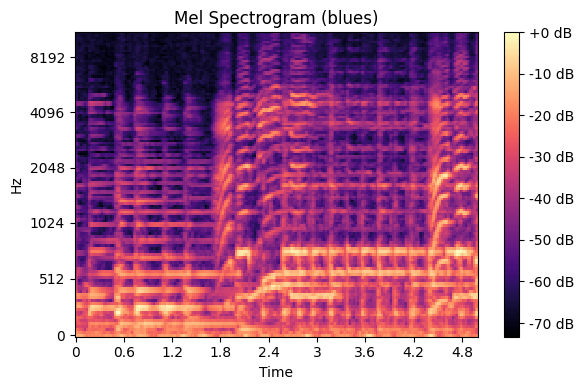

In [71]:
# do the test on one random file to check the functions if they work
test_path, test_label = random.choice(all_files)
print("Testing file:", test_path)
print("Label index:", test_label, " -> genre:", idx_to_genre[test_label])

y_test, sr_test = load_audio(test_path)
print("Waveform shape:", y_test.shape, " sample rate:", sr_test)

S_db_test = audio_to_mel_spectrogram(y_test, sr_test)
print("Spectrogram shape (mel x time):", S_db_test.shape)

plt.figure(figsize=(6,4))
librosa.display.specshow(S_db_test, sr=sr_test, hop_length=HOP_LENGTH,
                         x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Mel Spectrogram ({idx_to_genre[test_label]})")
plt.tight_layout()
plt.show()

In [72]:
from torchvision import transforms
import torch.nn.functional as F
import random

# Transform to resize spectrograms for ViT
vit_transform = transforms.Resize((224, 224))

class GTZANSpectrogramDatasetVIT(Dataset):
    """
    Same as GTZANSpectrogramDataset, but adds a resize transform so
    spectrograms fit the ViT input size.
    """
    def __init__(self, file_label_list, transform=None, augment=False):
        self.file_label_list = file_label_list
        self.transform = transform
        self.augment = augment

    def __len__(self):
        return len(self.file_label_list)

    def __getitem__(self, idx):
        path, label = self.file_label_list[idx]

        # Load fixed-length waveform
        y, sr = load_audio(path)

        # Convert waveform to log-mel spectrogram
        S_db = audio_to_mel_spectrogram(y, sr)

        # Normalize spectrogram values to [0,1]
        S_min, S_max = S_db.min(), S_db.max()
        S_norm = (S_db - S_min) / (S_max - S_min + 1e-8)

        # To tensor with 3 channels
        S_tensor = torch.tensor(S_norm, dtype=torch.float32)  # (H, W)
        S_tensor = S_tensor.repeat(3, 1, 1)                   # (3, H, W)

        if self.augment:
            S_tensor = spec_augment(S_tensor)

        # Resize for ViT if transform given
        if self.transform is not None:
            S_tensor = self.transform(S_tensor)               # (3, 224, 224)

        label = torch.tensor(label, dtype=torch.long)
        return S_tensor, label
    
# Make sure all_files exists and is shuffled
random.shuffle(all_files)

N = len(all_files)
n_train = int(0.8 * N)
n_val   = int(0.1 * N)
n_test  = N - n_train - n_val

train_files = all_files[:n_train]
val_files   = all_files[n_train:n_train+n_val]
test_files  = all_files[n_train+n_val:]

print("Train size:", len(train_files))
print("Val size:", len(val_files))
print("Test size:", len(test_files))

def spec_augment(spec, max_time_mask=30, max_freq_mask=20):
    """
    spec: (3, H, W) tensor. We will mask along time (W) and freq (H).
    """
    c, h, w = spec.shape

    # time mask
    t = random.randint(0, max_time_mask)
    t0 = random.randint(0, max(1, w - t))
    spec[:, :, t0:t0 + t] = 0.0

    # freq mask
    f = random.randint(0, max_freq_mask)
    f0 = random.randint(0, max(1, h - f))
    spec[:, f0:f0 + f, :] = 0.0

    return spec


Train size: 799
Val size: 99
Test size: 101


In [73]:
# Re-create datasets specifically for ViT (resized spectrograms)
train_dataset_vit = GTZANSpectrogramDatasetVIT(train_files, transform=vit_transform)
val_dataset_vit   = GTZANSpectrogramDatasetVIT(val_files,   transform=vit_transform)
test_dataset_vit  = GTZANSpectrogramDatasetVIT(test_files,  transform=vit_transform)

BATCH_SIZE = 10

train_loader_vit = DataLoader(train_dataset_vit, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader_vit   = DataLoader(val_dataset_vit,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_vit  = DataLoader(test_dataset_vit,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# sanity check
xb_vit, yb_vit = next(iter(train_loader_vit))
print("ViT batch shape:", xb_vit.shape)   # (B, 3, 224, 224)
print("ViT labels shape:", yb_vit.shape)


ViT batch shape: torch.Size([10, 3, 224, 224])
ViT labels shape: torch.Size([10])


In [74]:
from torchvision.models import vit_b_16, ViT_B_16_Weights
from torchvision import transforms

num_classes = 10  # already defined in your code

weights = ViT_B_16_Weights.DEFAULT
vit_model = vit_b_16(weights=weights)

# Replace head
in_features = vit_model.heads.head.in_features
vit_model.heads.head = nn.Linear(in_features, num_classes)
vit_model = vit_model.to(DEVICE)

# Extract just normalization
imagenet_mean = weights.transforms().mean
imagenet_std  = weights.transforms().std

vit_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])


In [75]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)              # (B, num_classes)
        loss = criterion(outputs, yb)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        _, preds = torch.max(outputs, dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            outputs = model(xb)
            loss = criterion(outputs, yb)

            running_loss += loss.item() * xb.size(0)
            _, preds = torch.max(outputs, dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [76]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(vit_model.parameters(), lr=3e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)  # 15 epochs

NUM_EPOCHS = 15
best_val_acc = 0.0
best_state_dict = None

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(vit_model, train_loader_vit, optimizer, criterion, DEVICE)
    val_loss, val_acc = evaluate(vit_model, val_loader_vit, criterion, DEVICE)

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_dict = vit_model.state_dict()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

if best_state_dict is not None:
    vit_model.load_state_dict(best_state_dict)
    print(f"Loaded best model with val acc = {best_val_acc:.4f}")


Epoch 01 | Train Loss: 1.9281, Train Acc: 0.2941 | Val Loss: 1.6824, Val Acc: 0.4242
Epoch 02 | Train Loss: 1.2415, Train Acc: 0.5745 | Val Loss: 1.2328, Val Acc: 0.5455
Epoch 03 | Train Loss: 0.9622, Train Acc: 0.6658 | Val Loss: 1.1337, Val Acc: 0.6061
Epoch 04 | Train Loss: 0.7541, Train Acc: 0.7622 | Val Loss: 1.2275, Val Acc: 0.6465
Epoch 05 | Train Loss: 0.6604, Train Acc: 0.7835 | Val Loss: 0.9957, Val Acc: 0.6869
Epoch 06 | Train Loss: 0.5846, Train Acc: 0.8198 | Val Loss: 0.8683, Val Acc: 0.7071
Epoch 07 | Train Loss: 0.5191, Train Acc: 0.8298 | Val Loss: 0.9521, Val Acc: 0.6869
Epoch 08 | Train Loss: 0.4471, Train Acc: 0.8586 | Val Loss: 1.1183, Val Acc: 0.6162
Epoch 09 | Train Loss: 0.3423, Train Acc: 0.8899 | Val Loss: 0.7811, Val Acc: 0.7374
Epoch 10 | Train Loss: 0.2990, Train Acc: 0.9136 | Val Loss: 0.9062, Val Acc: 0.7273
Epoch 11 | Train Loss: 0.2810, Train Acc: 0.9186 | Val Loss: 0.9170, Val Acc: 0.7071
Epoch 12 | Train Loss: 0.2474, Train Acc: 0.9299 | Val Loss: 0.79

Test Classification Report:
              precision    recall  f1-score   support

       blues       0.90      0.69      0.78        13
   classical       1.00      1.00      1.00         8
     country       0.38      0.83      0.53         6
       disco       0.91      0.91      0.91        11
      hiphop       0.82      0.75      0.78        12
        jazz       1.00      0.91      0.95        11
       metal       0.70      0.70      0.70        10
         pop       0.71      0.71      0.71         7
      reggae       0.90      0.75      0.82        12
        rock       0.45      0.45      0.45        11

    accuracy                           0.76       101
   macro avg       0.78      0.77      0.76       101
weighted avg       0.80      0.76      0.77       101



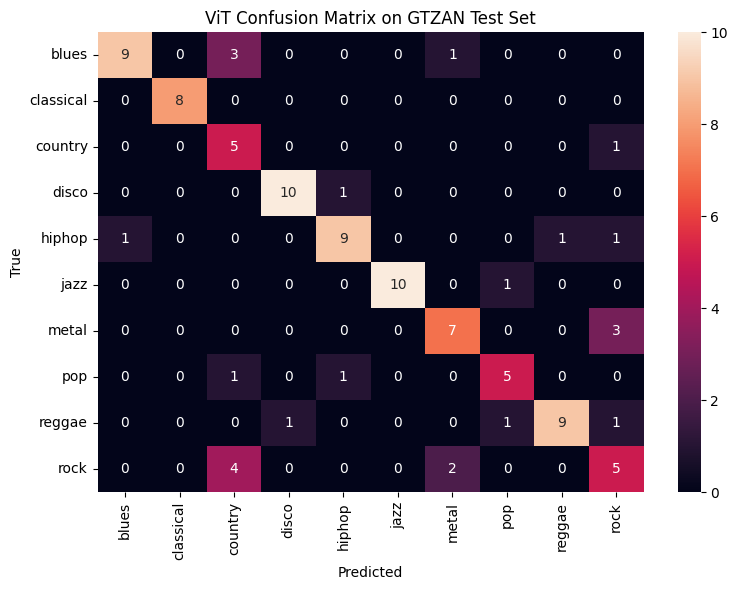

In [77]:
vit_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader_vit:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        outputs = vit_model(xb)
        _, preds = torch.max(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

print("Test Classification Report:")
print(classification_report(all_labels, all_preds, target_names=genres))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=genres, yticklabels=genres)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ViT Confusion Matrix on GTZAN Test Set")
plt.tight_layout()
plt.show()

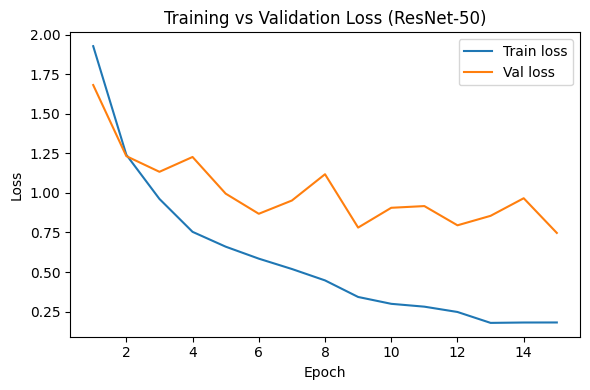

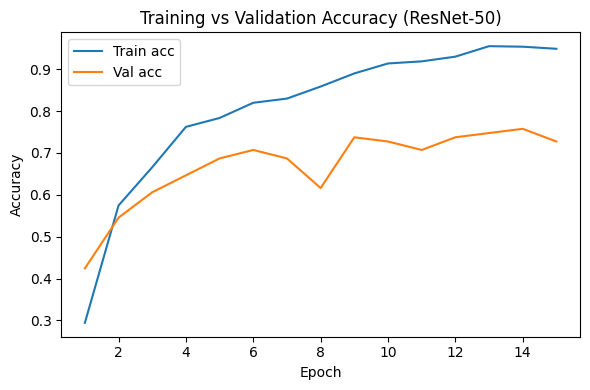

In [78]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, val_losses,   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (ResNet-50)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs, train_accs, label="Train acc")
plt.plot(epochs, val_accs,   label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (ResNet-50)")
plt.legend()
plt.tight_layout()
plt.show()
